# 📊 EDA — Empleo por Edad
**Fuente:** `e_por_edad.csv`  
**Descripción:** Empleo dependiente privado mensual en Lima Metropolitana según grupo de edad: Jóvenes (hasta 29 años), Adultos (30 a más años) y No Especificado. Período 2015–2025.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'joven': '#2ecc71', 'adulto': '#e67e22', 'no_esp': '#9b59b6'}
MES_ORDEN = {'ENE.':1,'FEB.':2,'MAR.':3,'ABR.':4,'MAY.':5,'JUN.':6,
             'JUL.':7,'AGO.':8,'SET.':9,'OCT.':10,'NOV.':11,'DIC.':12}
MESES_ETQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']
print('OK ✓')

OK ✓


## 1. Carga y Limpieza

In [3]:
df = pd.read_csv('e_por_edad.csv', sep=';', encoding='utf-8', on_bad_lines='skip')
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()
df.columns = ['anio', 'mes', 'joven', 'adulto', 'no_especificado']

for col in ['joven', 'adulto', 'no_especificado']:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['joven'], inplace=True)
df['anio'] = df['anio'].astype(int)
df['mes_num'] = df['mes'].map(MES_ORDEN)
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)
df['total'] = df['joven'] + df['adulto'] + df['no_especificado']

print(f'Shape: {df.shape}')
df.head()

Shape: (128, 8)


,anio,mes,joven,adulto,no_especificado,mes_num,fecha,total
0,2015,ENE.,986681,2011739,131935,1,2015-01-01,3130355
1,2015,FEB.,967543,2004222,146746,2,2015-02-01,3118511
2,2015,MAR.,960674,2040313,169068,3,2015-03-01,3170055
3,2015,ABR.,952392,2075866,183525,4,2015-04-01,3211783
4,2015,MAY.,944818,2088521,185887,5,2015-05-01,3219226


## 2. Estadísticas Descriptivas

In [4]:
desc = df[['joven','adulto','no_especificado','total']].describe().round(0)
desc.index = ['Conteo','Media','Desv. Est.','Mín','Q25','Mediana','Q75','Máx']
desc

,joven,adulto,no_especificado,total
Conteo,128.0,128.0,128.0,128.0
Media,1027777.0,2397032.0,214145.0,3638953.0
Desv. Est.,89551.0,254485.0,41049.0,369698.0
Mín,711818.0,1924834.0,131935.0,2810882.0
Q25,974655.0,2193638.0,175468.0,3351678.0
Mediana,1024197.0,2344094.0,220535.0,3556945.0
Q75,1078703.0,2585168.0,247355.0,3919678.0
Máx,1228078.0,2961780.0,283142.0,4454406.0


In [5]:
print('Rango:', df['fecha'].min().strftime('%b %Y'), '→', df['fecha'].max().strftime('%b %Y'))
print('Nulos:', df.isnull().sum().to_dict())

Rango: Jan 2015 → Aug 2025
Nulos: {'anio': 0, 'mes': 0, 'joven': 0, 'adulto': 0, 'no_especificado': 0, 'mes_num': 0, 'fecha': 0, 'total': 0}


## 3. Serie de Tiempo — Empleo por Grupo de Edad

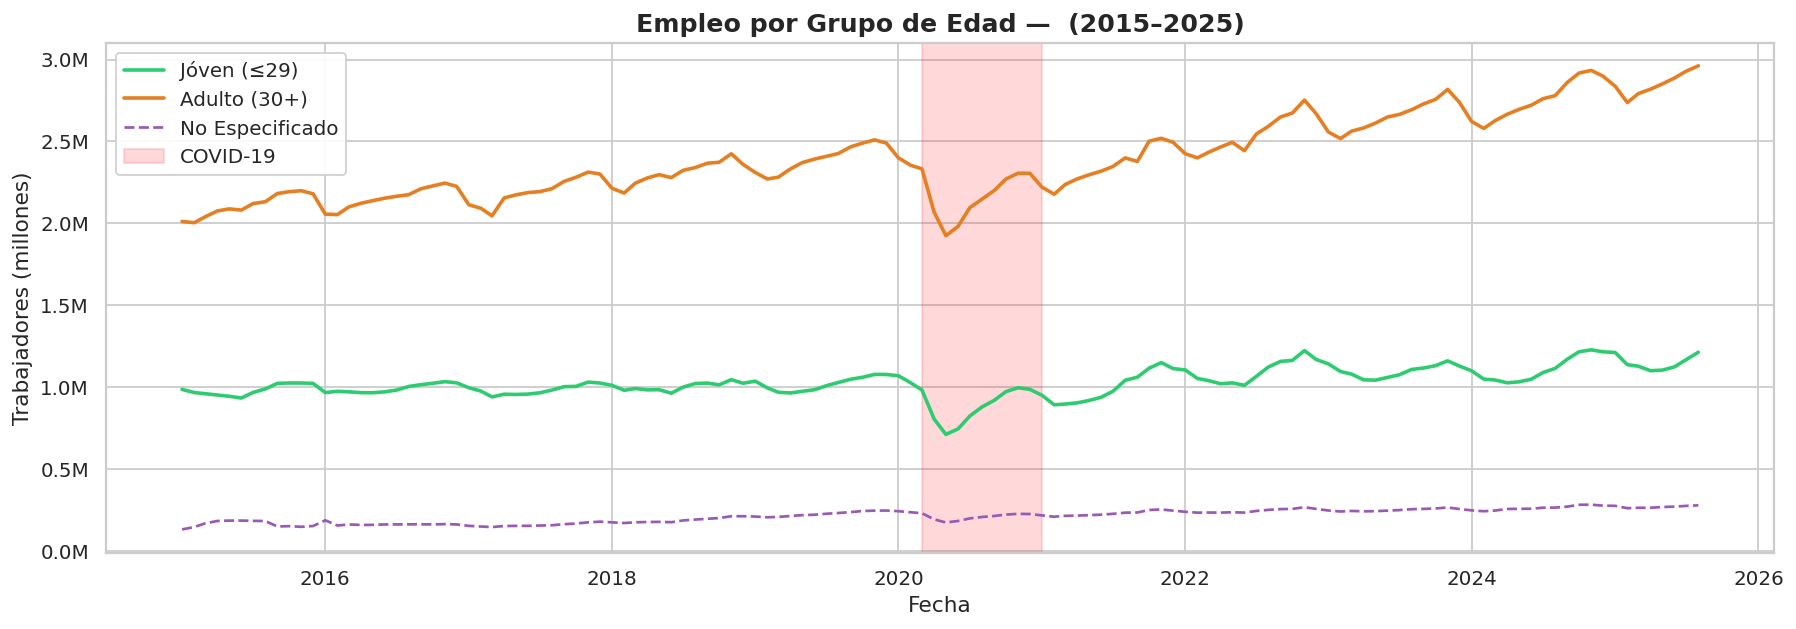

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['fecha'], df['joven']/1e6, label='Jóven (≤29)', color=COLORS['joven'], lw=2)
ax.plot(df['fecha'], df['adulto']/1e6, label='Adulto (30+)', color=COLORS['adulto'], lw=2)
ax.plot(df['fecha'], df['no_especificado']/1e6, label='No Especificado', color=COLORS['no_esp'], lw=1.5, ls='--')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='red', label='COVID-19')
ax.set_title('Empleo por Grupo de Edad —  (2015–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## 4. Promedio Anual por Grupo de Edad

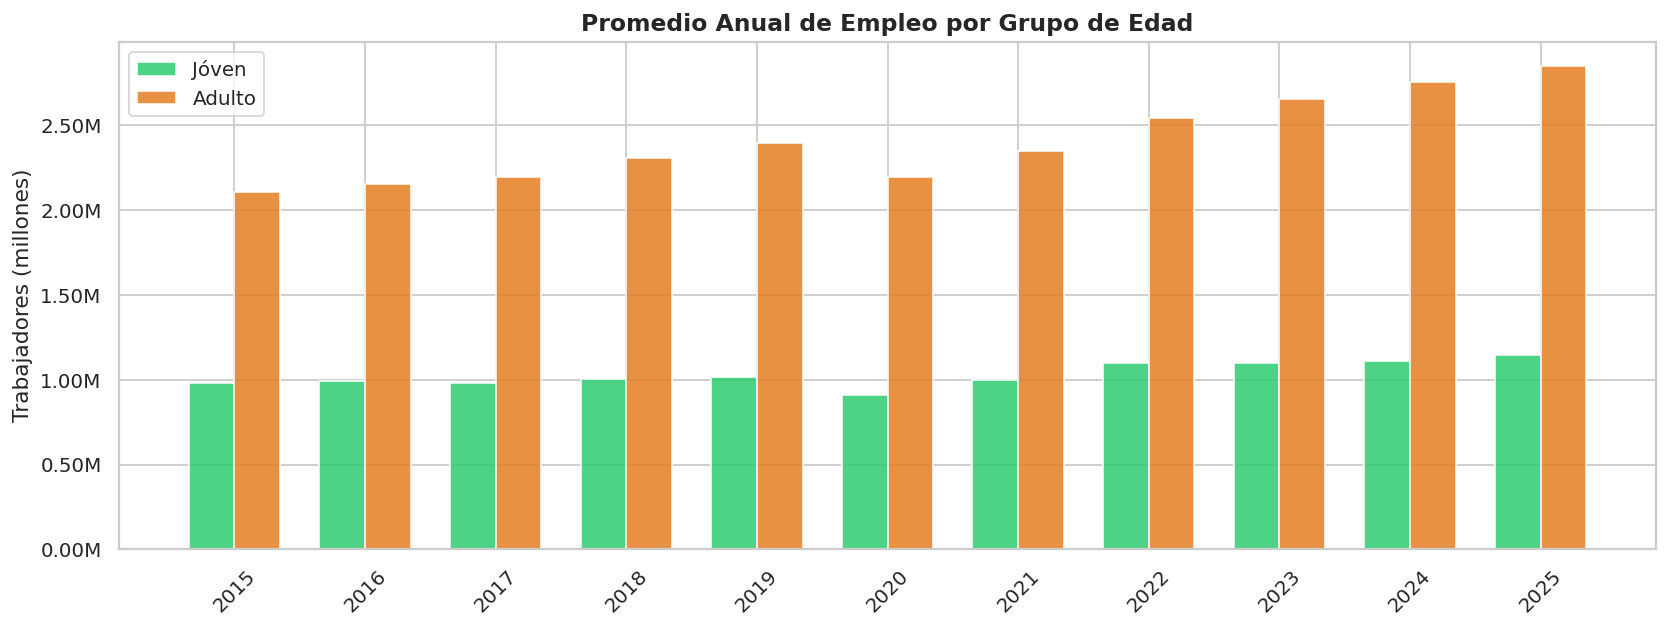

In [8]:
anual = df.groupby('anio')[['joven','adulto']].mean().reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(anual))
w = 0.35
ax.bar(x - w/2, anual['joven']/1e6, w, label='Jóven', color=COLORS['joven'], alpha=0.85)
ax.bar(x + w/2, anual['adulto']/1e6, w, label='Adulto', color=COLORS['adulto'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(anual['anio'].astype(int), rotation=45)
ax.set_title('Promedio Anual de Empleo por Grupo de Edad', fontsize=13, fontweight='bold')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Participación Porcentual Jóvenes vs Adultos

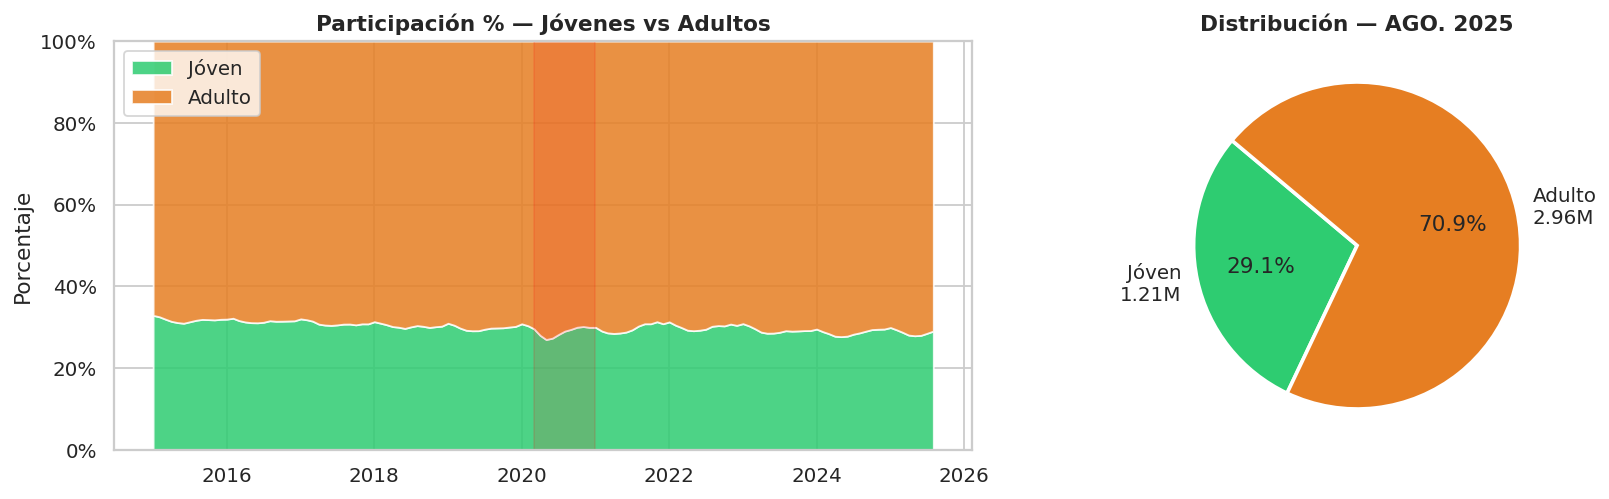

In [9]:
df['total_2cat'] = df['joven'] + df['adulto']
df['pct_joven'] = df['joven'] / df['total_2cat'] * 100
df['pct_adulto'] = df['adulto'] / df['total_2cat'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Stack area
axes[0].stackplot(df['fecha'], df['pct_joven'], df['pct_adulto'],
                  labels=['Jóven', 'Adulto'],
                  colors=[COLORS['joven'], COLORS['adulto']], alpha=0.85)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.12, color='red')
axes[0].set_title('Participación % — Jóvenes vs Adultos', fontweight='bold')
axes[0].set_ylabel('Porcentaje')
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(loc='upper left')

# Pie último mes
ultimo = df.iloc[-1]
sizes = [ultimo['joven'], ultimo['adulto']]
labels = [f'Jóven\n{sizes[0]/1e6:.2f}M', f'Adulto\n{sizes[1]/1e6:.2f}M']
axes[1].pie(sizes, labels=labels, colors=[COLORS['joven'], COLORS['adulto']],
            autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Distribución — {ultimo["mes"]} {int(ultimo["anio"])}', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Estacionalidad Mensual

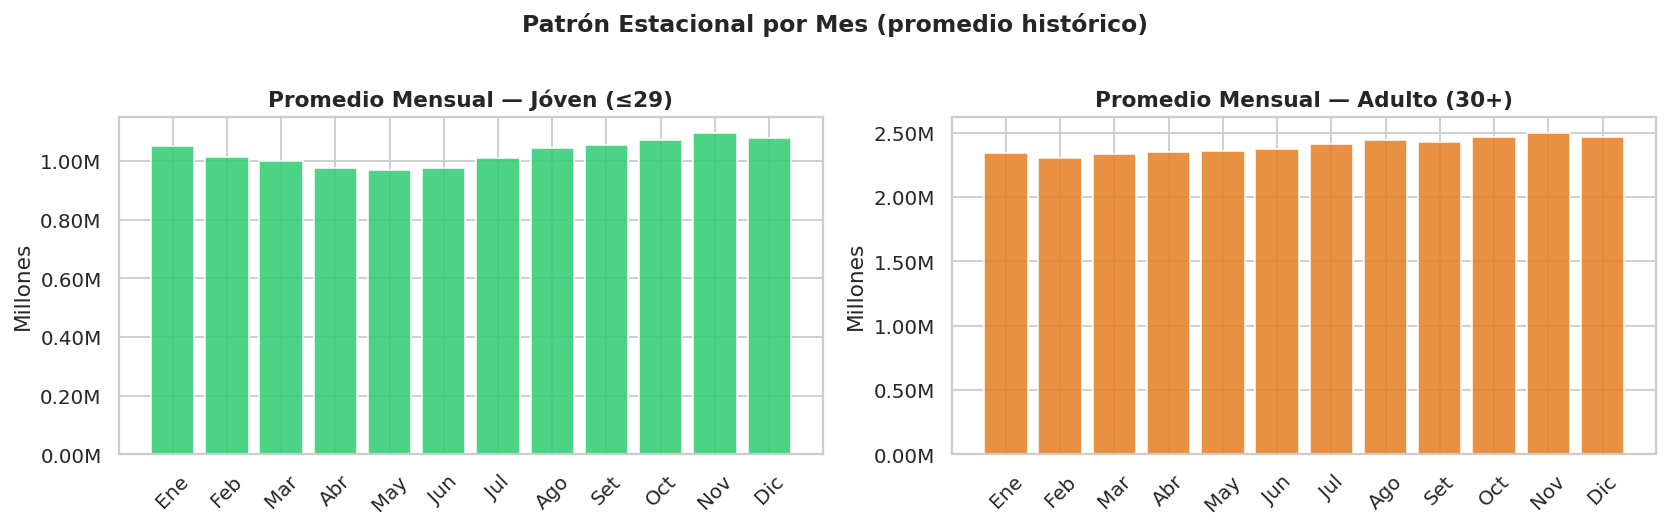

In [10]:
estac = df.groupby('mes_num')[['joven','adulto']].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, titulo in zip(axes,
    ['joven','adulto'], [COLORS['joven'], COLORS['adulto']], ['Jóven (≤29)','Adulto (30+)']):
    ax.bar(range(1,13), estac[col]/1e6, color=color, alpha=0.85)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MESES_ETQ, rotation=45)
    ax.set_title(f'Promedio Mensual — {titulo}', fontweight='bold')
    ax.set_ylabel('Millones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
plt.suptitle('Patrón Estacional por Mes (promedio histórico)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Mapa de Calor — Empleo Jóvenes por Año-Mes

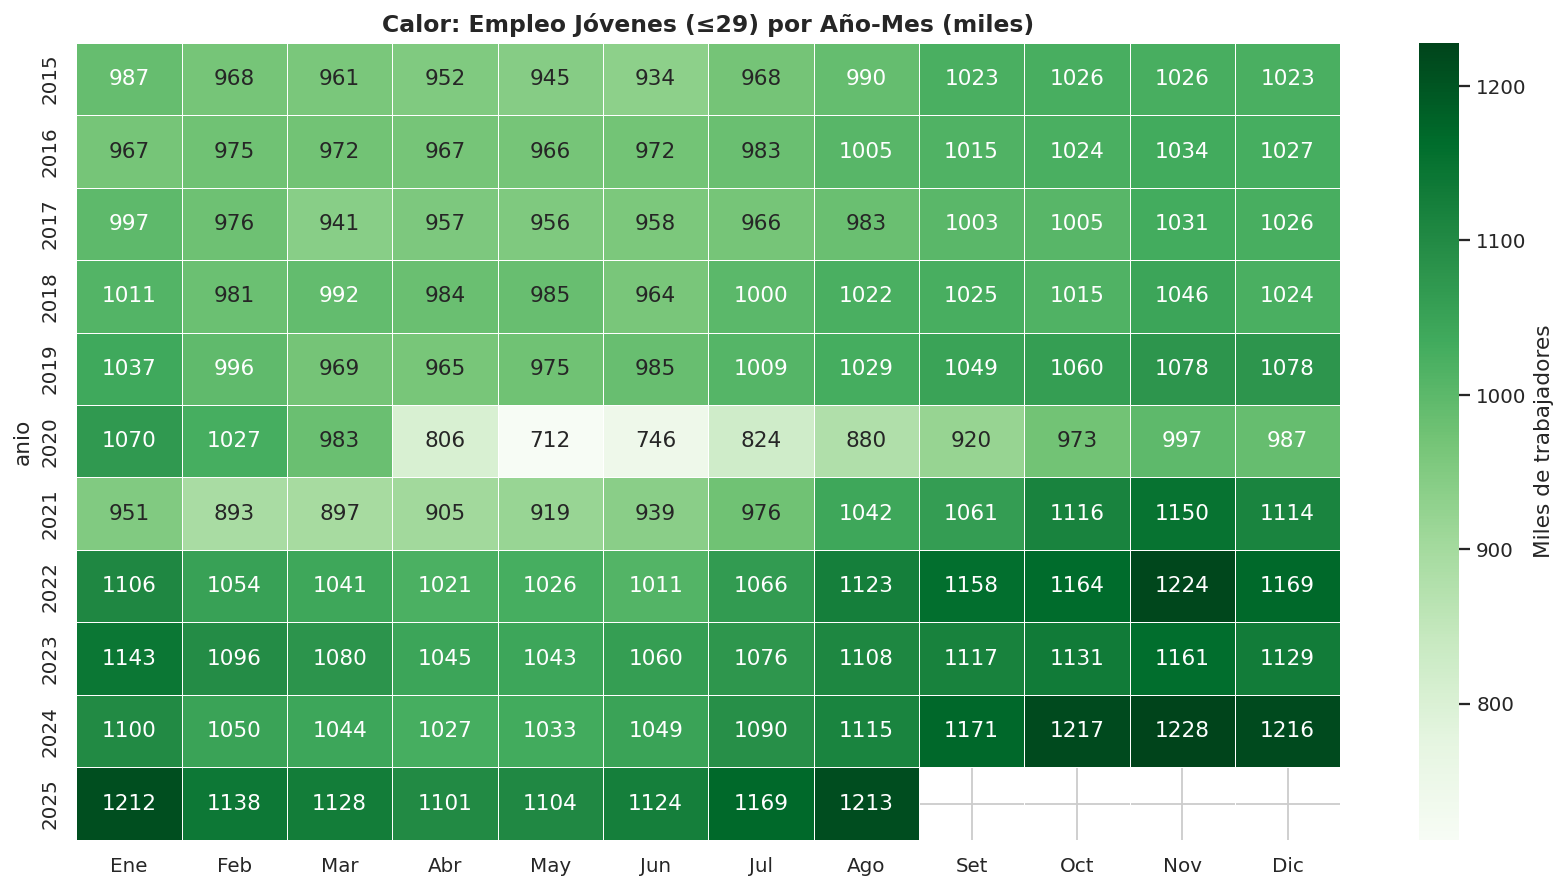

In [11]:
pivot = df.pivot_table(index='anio', columns='mes_num', values='joven', aggfunc='mean')
pivot.columns = MESES_ETQ[:len(pivot.columns)]
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='Greens',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Miles de trabajadores'})
ax.set_title('Calor: Empleo Jóvenes (≤29) por Año-Mes (miles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Ratio Jóvenes/Adultos a lo Largo del Tiempo

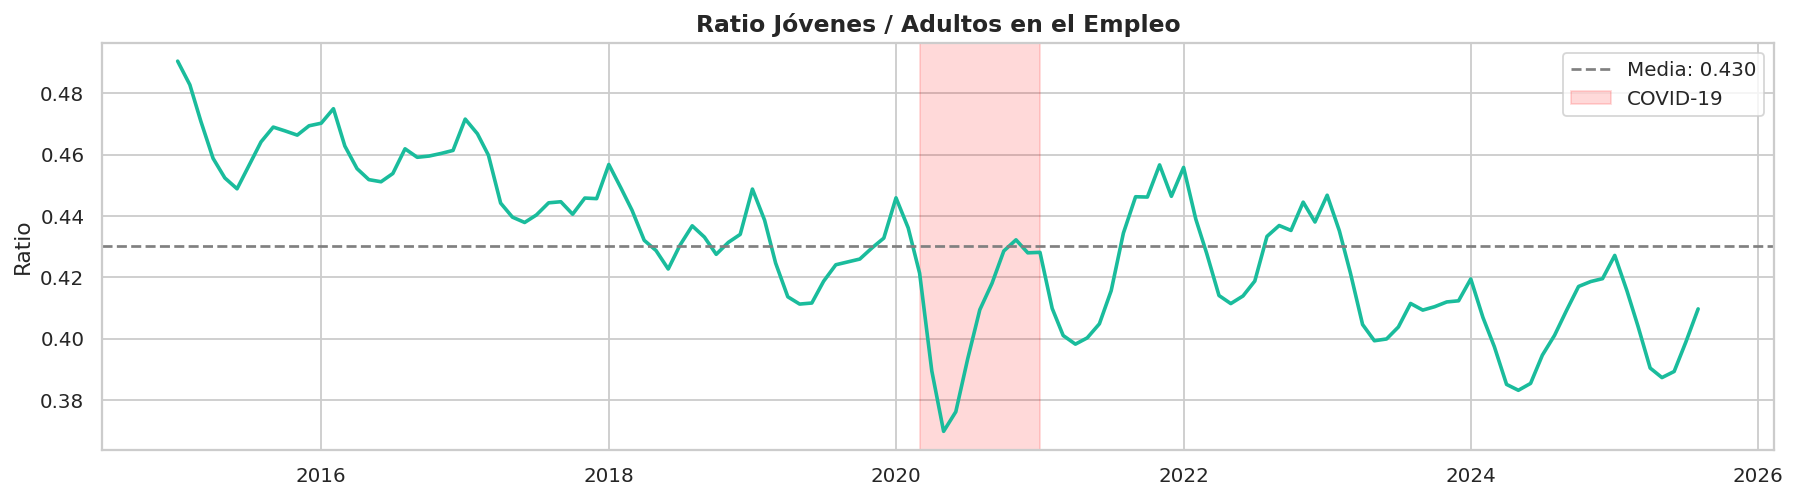

In [12]:
df['ratio_joven_adulto'] = df['joven'] / df['adulto']
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['fecha'], df['ratio_joven_adulto'], color='#1abc9c', lw=2)
ax.axhline(df['ratio_joven_adulto'].mean(), color='gray', ls='--', lw=1.5, label=f'Media: {df["ratio_joven_adulto"].mean():.3f}')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='red', label='COVID-19')
ax.set_title('Ratio Jóvenes / Adultos en el Empleo', fontsize=13, fontweight='bold')
ax.set_ylabel('Ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Crecimiento Interanual

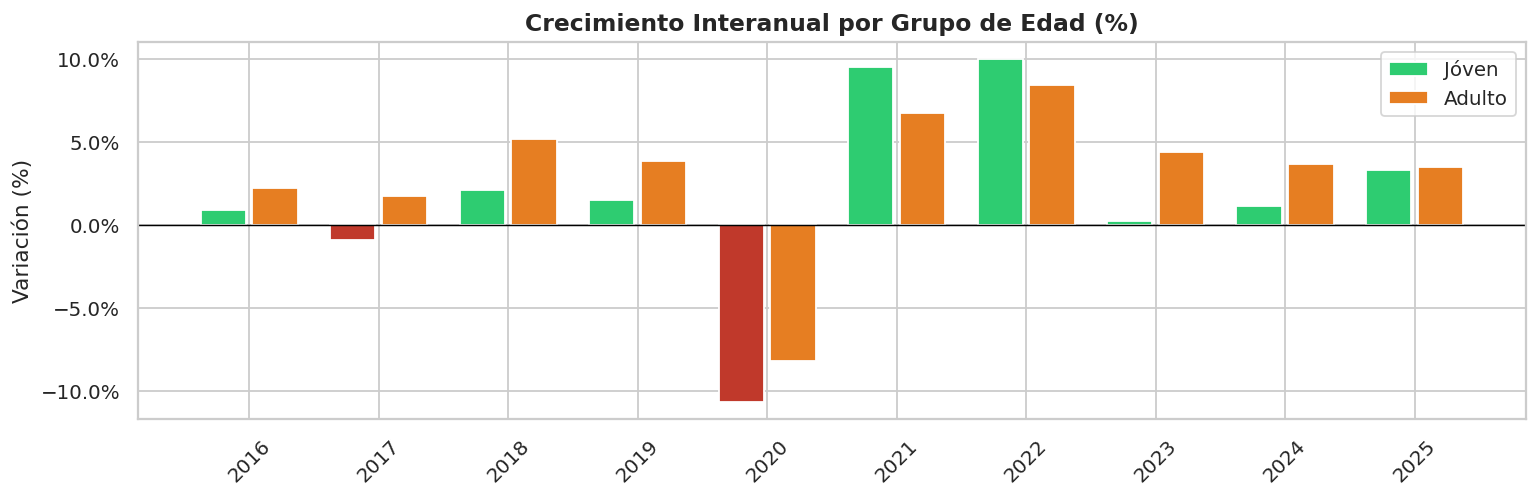

In [13]:
anual_mean = df.groupby('anio')[['joven','adulto']].mean()
crec = anual_mean.pct_change() * 100
crec = crec.dropna()
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(crec))
ax.bar(x - 0.2, crec['joven'], 0.35, label='Jóven',
       color=[COLORS['joven'] if v >= 0 else '#c0392b' for v in crec['joven']])
ax.bar(x + 0.2, crec['adulto'], 0.35, label='Adulto',
       color=[COLORS['adulto'] if v >= 0 else '#e67e22' for v in crec['adulto']])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crec.index.astype(int), rotation=45)
ax.set_title('Crecimiento Interanual por Grupo de Edad (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Variación (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

| Métrica | Jóvenes (≤29) | Adultos (30+) |
|---------|--------------|---------------|
| Promedio mensual | ~1,020 K | ~2,430 K |
| Máximo | ~1,228 K (Nov 2024) | ~2,961 K (Ago 2025) |
| Mínimo | ~712 K (May 2020) | ~1,925 K (May 2020) |
| Tendencia | ▲ Creciente | ▲ Creciente |

**Observaciones clave:**
- Los **adultos** representan ~70% del empleo, los **jóvenes** ~30%.
- El **ratio jóvenes/adultos** ha disminuido levemente a lo largo de los años, sugiriendo envejecimiento de la fuerza laboral.
- El **COVID-19** impactó más a los jóvenes en términos relativos.
- La estacionalidad es más pronunciada en **jóvenes** que en adultos (variaciones de hasta ±10% entre meses).